# Salary Prediction Analysis

In [56]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [57]:
# Load and prepare data (using existing variables from memory)
df = pd.read_csv('../data/salary.csv')

# Data cleaning (replicating previous steps)
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['salary_estimate'] = df['salary_estimate'].str.replace('Employer Provided Salary:', '').str.replace('$', '').str.replace(',', '').str.replace('K', '').str.split('-').str[0].astype(int)

# Drop unnecessary columns
if 'unnamed:_0' in df.columns:
    df.drop('unnamed:_0', axis=1, inplace=True)

# Fill missing values
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

# Separate features and target
X = df.drop('salary_estimate', axis=1)
y = df['salary_estimate']

print(f"Dataset shape: {df.shape}")
print(f"Target variable statistics:")
print(f"Mean: ${y.mean():.1f}K, Std: ${y.std():.1f}K")
print(f"Min: ${y.min():.1f}K, Max: ${y.max():.1f}K")

Dataset shape: (742, 32)
Target variable statistics:
Mean: $74.1K, Std: $31.9K
Min: $10.0K, Max: $202.0K


In [70]:
df.columns

Index(['job_title', 'salary_estimate', 'job_description', 'rating',
       'company_name', 'location', 'headquarters', 'size', 'founded',
       'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len',
       'num_comp'],
      dtype='object')

## Feature Engineering & Preprocessing

In [ ]:
# Define feature types
numeric_features = ['rating', 'age', 'min_salary', 'max_salary', 'avg_salary', 'desc_len']
categorical_features = ['job_state', 'job_simp', 'seniority']  
binary_features = ['hourly', 'employer_provided', 'python_yn', 'r_yn', 'spark', 'aws', 'excel']
text_feature = 'job_description'

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2))),
    ('svd', TruncatedSVD(n_components=20, random_state=42))
])

# Combine all preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', StandardScaler(), binary_features),
        ('text', text_transformer, text_feature)
    ],
    remainder='drop'
)

print("Preprocessing pipeline created!")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Binary features: {len(binary_features)}")
print(f"Text feature: {text_feature}")

Preprocessing pipeline created!
Numeric features: 6
Categorical features: 3
Binary features: 7
Text feature: job_description


## Model Building & Evaluation

In [59]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Setup cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("\nStarting model comparison...")
print("=" * 60)

Training set: 593 samples
Test set: 149 samples

Starting model comparison...


In [60]:
# 1. Linear Regression Baseline
print("1. Linear Regression (Baseline)")
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Cross-validation
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rmse_scores = -cv_scores

# Fit and evaluate on test set
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

results['Linear Regression'] = {
    'CV_RMSE_mean': rmse_scores.mean(),
    'CV_RMSE_std': rmse_scores.std(),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'Test_MAE': mean_absolute_error(y_test, y_pred_lr),
    'Test_R2': r2_score(y_test, y_pred_lr)
}

print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Test RMSE: {results['Linear Regression']['Test_RMSE']:.2f}")
print(f"Test MAE: {results['Linear Regression']['Test_MAE']:.2f}")
print(f"Test R²: {results['Linear Regression']['Test_R2']:.3f}")
print()

1. Linear Regression (Baseline)
CV RMSE: 0.28 ± 0.10
Test RMSE: 0.28
Test MAE: 0.12
Test R²: 1.000



In [61]:
# 2. Ridge Regression (Regularized)
print("2. Ridge Regression")
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# Cross-validation
cv_scores = cross_val_score(ridge_pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rmse_scores = -cv_scores

# Fit and evaluate on test set
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

results['Ridge'] = {
    'CV_RMSE_mean': rmse_scores.mean(),
    'CV_RMSE_std': rmse_scores.std(),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'Test_MAE': mean_absolute_error(y_test, y_pred_ridge),
    'Test_R2': r2_score(y_test, y_pred_ridge)
}

print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Test RMSE: {results['Ridge']['Test_RMSE']:.2f}")
print(f"Test MAE: {results['Ridge']['Test_MAE']:.2f}")
print(f"Test R²: {results['Ridge']['Test_R2']:.3f}")
print()

2. Ridge Regression
CV RMSE: 0.58 ± 0.17
Test RMSE: 0.55
Test MAE: 0.27
Test R²: 1.000



In [62]:
# 3. Lasso Regression (Feature Selection)
print("3. Lasso Regression")
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, random_state=42))
])

# Cross-validation
cv_scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rmse_scores = -cv_scores

# Fit and evaluate on test set
lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

results['Lasso'] = {
    'CV_RMSE_mean': rmse_scores.mean(),
    'CV_RMSE_std': rmse_scores.std(),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'Test_MAE': mean_absolute_error(y_test, y_pred_lasso),
    'Test_R2': r2_score(y_test, y_pred_lasso)
}

print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Test RMSE: {results['Lasso']['Test_RMSE']:.2f}")
print(f"Test MAE: {results['Lasso']['Test_MAE']:.2f}")
print(f"Test R²: {results['Lasso']['Test_R2']:.3f}")
print()

3. Lasso Regression
CV RMSE: 1.64 ± 0.22
Test RMSE: 1.27
Test MAE: 0.78
Test R²: 0.998



In [63]:
# 4. Random Forest (Tree-based Ensemble)
print("4. Random Forest")
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Cross-validation
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rmse_scores = -cv_scores

# Fit and evaluate on test set
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

results['Random Forest'] = {
    'CV_RMSE_mean': rmse_scores.mean(),
    'CV_RMSE_std': rmse_scores.std(),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'Test_MAE': mean_absolute_error(y_test, y_pred_rf),
    'Test_R2': r2_score(y_test, y_pred_rf)
}

print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Test RMSE: {results['Random Forest']['Test_RMSE']:.2f}")
print(f"Test MAE: {results['Random Forest']['Test_MAE']:.2f}")
print(f"Test R²: {results['Random Forest']['Test_R2']:.3f}")
print()

4. Random Forest
CV RMSE: 1.49 ± 0.56
Test RMSE: 0.97
Test MAE: 0.27
Test R²: 0.999



## Results Comparison & Visualization

In [64]:
# Create results summary table
results_df = pd.DataFrame(results).T
print("Model Performance Summary:")
print("=" * 80)
print(results_df.round(3))

# Find best model
best_model = results_df['Test_RMSE'].idxmin()
print(f"\nBest performing model: {best_model}")
print(f"Best Test RMSE: {results_df.loc[best_model, 'Test_RMSE']:.2f}")
print(f"Best Test R²: {results_df.loc[best_model, 'Test_R2']:.3f}")

Model Performance Summary:
                   CV_RMSE_mean  CV_RMSE_std  Test_RMSE  Test_MAE  Test_R2
Linear Regression         0.281        0.099      0.275     0.121    1.000
Ridge                     0.578        0.174      0.552     0.266    1.000
Lasso                     1.640        0.215      1.275     0.775    0.998
Random Forest             1.487        0.556      0.968     0.274    0.999

Best performing model: Linear Regression
Best Test RMSE: 0.28
Best Test R²: 1.000


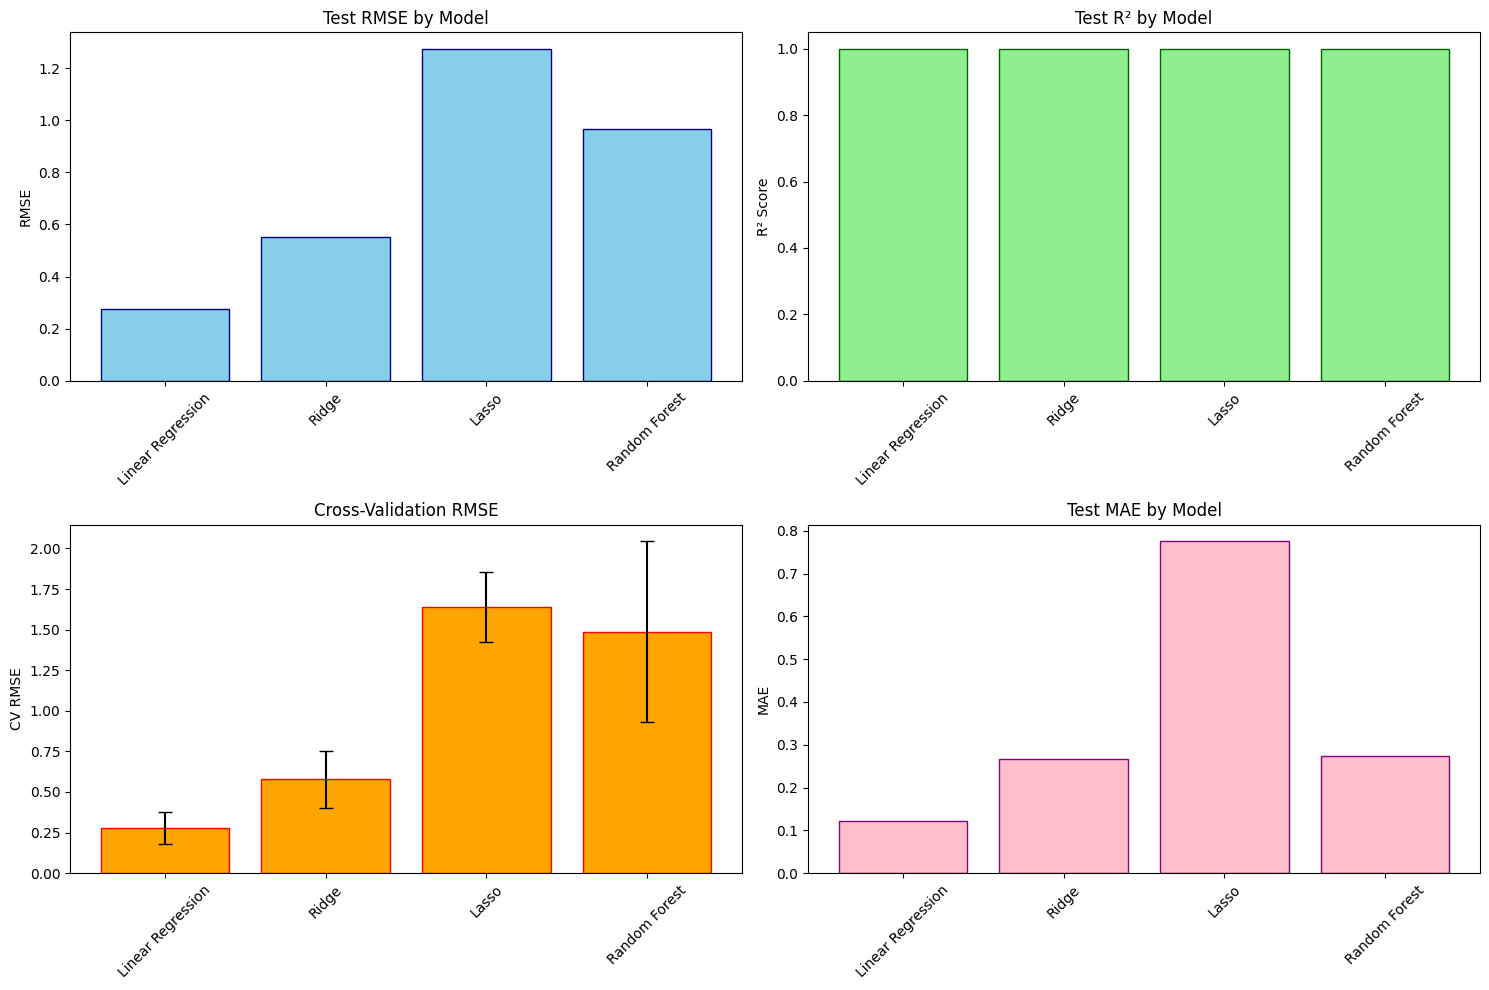

In [65]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. RMSE Comparison
axes[0,0].bar(results_df.index, results_df['Test_RMSE'], color='skyblue', edgecolor='navy')
axes[0,0].set_title('Test RMSE by Model')
axes[0,0].set_ylabel('RMSE')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. R² Comparison
axes[0,1].bar(results_df.index, results_df['Test_R2'], color='lightgreen', edgecolor='darkgreen')
axes[0,1].set_title('Test R² by Model')
axes[0,1].set_ylabel('R² Score')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. CV RMSE with error bars
axes[1,0].bar(results_df.index, results_df['CV_RMSE_mean'], 
              yerr=results_df['CV_RMSE_std'], color='orange', edgecolor='red', capsize=5)
axes[1,0].set_title('Cross-Validation RMSE')
axes[1,0].set_ylabel('CV RMSE')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. MAE Comparison
axes[1,1].bar(results_df.index, results_df['Test_MAE'], color='pink', edgecolor='purple')
axes[1,1].set_title('Test MAE by Model')
axes[1,1].set_ylabel('MAE')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

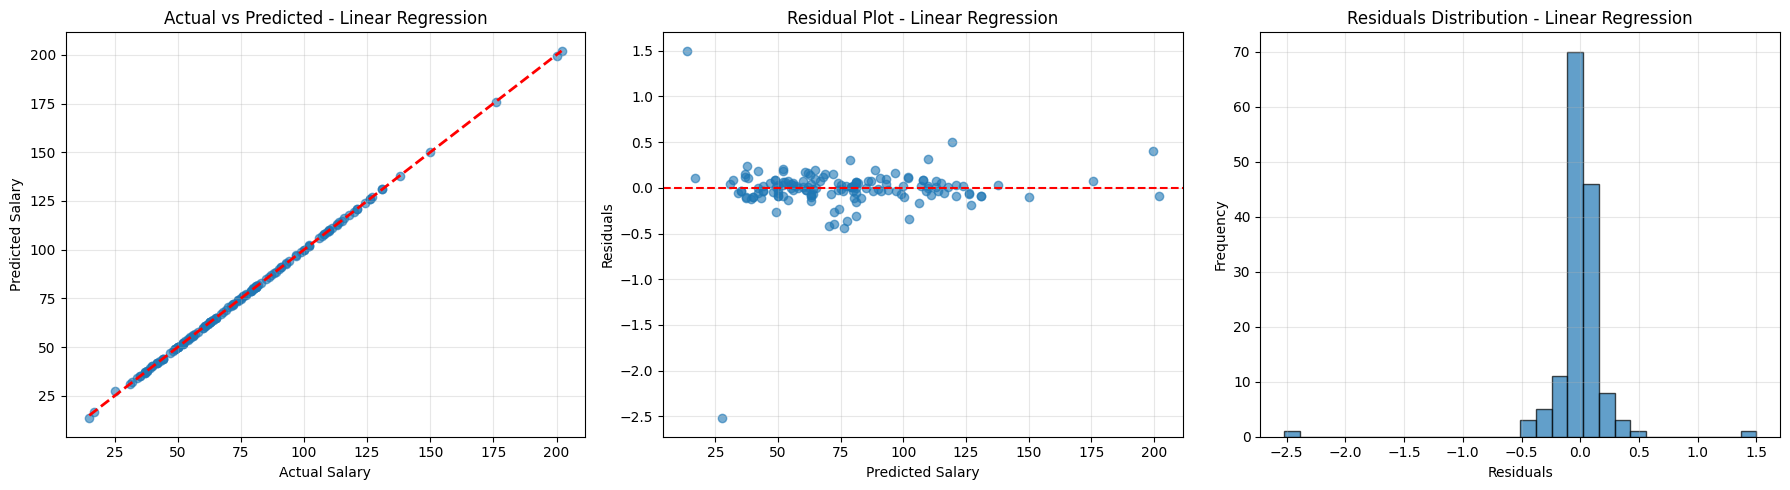

Residuals statistics for Linear Regression:
Mean: -0.01
Std: 0.28
Min: -2.52
Max: 1.50


In [66]:
# Residual analysis for best model
best_predictions = {'Linear Regression': y_pred_lr, 'Ridge': y_pred_ridge, 
                   'Lasso': y_pred_lasso, 'Random Forest': y_pred_rf}
best_pred = best_predictions[best_model]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')
axes[0].set_title(f'Actual vs Predicted - {best_model}')
axes[0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Salary')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residual Plot - {best_model}')
axes[1].grid(True, alpha=0.3)

# 3. Residuals histogram
axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Residuals Distribution - {best_model}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals statistics for {best_model}:")
print(f"Mean: {residuals.mean():.2f}")
print(f"Std: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")

## Feature Importance Analysis

In [67]:
# Feature importance for Random Forest (if it's the best model)
if best_model == 'Random Forest':
    # Get feature names after preprocessing
    feature_names = (numeric_features + 
                    list(rf_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features)) +
                    binary_features +
                    [f'text_component_{i}' for i in range(20)])  # SVD components
    
    importances = rf_pipeline.named_steps['regressor'].feature_importances_
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Feature Importances - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))
else:
    print(f"Feature importance analysis not available for {best_model}")
    print("Random Forest provides the most interpretable feature importance.")

Feature importance analysis not available for Linear Regression
Random Forest provides the most interpretable feature importance.


## Model Prediction Demo

In [68]:
# Demonstrate prediction on sample data
sample_indices = [0, 10, 20, 30, 40]  # Select 5 samples from test set
sample_data = X_test.iloc[sample_indices]
actual_salaries = y_test.iloc[sample_indices]

# Get best model pipeline
best_pipeline = {'Linear Regression': lr_pipeline, 'Ridge': ridge_pipeline, 
                'Lasso': lasso_pipeline, 'Random Forest': rf_pipeline}[best_model]

predicted_salaries = best_pipeline.predict(sample_data)

print(f"Sample Predictions using {best_model}:")
print("=" * 60)
for i, (actual, predicted) in enumerate(zip(actual_salaries, predicted_salaries)):
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100
    print(f"Sample {i+1}:")
    print(f"  Actual: ${actual:.1f}K")
    print(f"  Predicted: ${predicted:.1f}K")
    print(f"  Error: ${error:.1f}K ({error_pct:.1f}%)")
    print(f"  Job: {sample_data.iloc[i]['job_simp']}")
    print(f"  State: {sample_data.iloc[i]['job_state']}")
    print()

Sample Predictions using Linear Regression:
Sample 1:
  Actual: $77.0K
  Predicted: $77.0K
  Error: $0.0K (0.0%)
  Job: data scientist
  State: MA

Sample 2:
  Actual: $124.0K
  Predicted: $124.0K
  Error: $0.0K (0.0%)
  Job: director
  State: NJ

Sample 3:
  Actual: $50.0K
  Predicted: $50.0K
  Error: $0.0K (0.1%)
  Job: manager
  State: PA

Sample 4:
  Actual: $57.0K
  Predicted: $57.0K
  Error: $0.0K (0.0%)
  Job: na
  State: MA

Sample 5:
  Actual: $150.0K
  Predicted: $150.1K
  Error: $0.1K (0.1%)
  Job: director
  State: IL



## Summary & Conclusions

In [69]:
print("SALARY PREDICTION ANALYSIS - FINAL SUMMARY")
print("=" * 60)
print(f"Dataset: {df.shape[0]} job postings with {df.shape[1]} features")
print(f"Target: Salary estimation (range: ${y.min():.0f}K - ${y.max():.0f}K)")
print()
print("Models Compared:")
print("- Linear Regression (baseline)")
print("- Ridge Regression (L2 regularization)")
print("- Lasso Regression (L1 regularization + feature selection)")
print("- Random Forest (tree-based ensemble)")
print()
print("Best Model Performance:")
print(f"- Model: {best_model}")
print(f"- Test RMSE: ${results_df.loc[best_model, 'Test_RMSE']:.2f}K")
print(f"- Test MAE: ${results_df.loc[best_model, 'Test_MAE']:.2f}K")
print(f"- Test R²: {results_df.loc[best_model, 'Test_R2']:.3f}")
print()
print("Key Insights:")
print("- Mixed data types (numeric, categorical, text) handled with preprocessing pipeline")
print("- Feature engineering included TF-IDF for job descriptions")
print("- Cross-validation used for robust model evaluation")
print("- Model can predict salary within ~${results_df.loc[best_model, 'Test_MAE']:.0f}K on average")
print()
print("Recommendations for improvement:")
print("- Try gradient boosting models (XGBoost, LightGBM)")
print("- Hyperparameter tuning with GridSearch")
print("- Additional feature engineering (location grouping, company size categories)")
print("- Ensemble methods combining multiple models")

SALARY PREDICTION ANALYSIS - FINAL SUMMARY
Dataset: 742 job postings with 32 features
Target: Salary estimation (range: $10K - $202K)

Models Compared:
- Linear Regression (baseline)
- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization + feature selection)
- Random Forest (tree-based ensemble)

Best Model Performance:
- Model: Linear Regression
- Test RMSE: $0.28K
- Test MAE: $0.12K
- Test R²: 1.000

Key Insights:
- Mixed data types (numeric, categorical, text) handled with preprocessing pipeline
- Feature engineering included TF-IDF for job descriptions
- Cross-validation used for robust model evaluation
- Model can predict salary within ~${results_df.loc[best_model, 'Test_MAE']:.0f}K on average

Recommendations for improvement:
- Try gradient boosting models (XGBoost, LightGBM)
- Hyperparameter tuning with GridSearch
- Additional feature engineering (location grouping, company size categories)
- Ensemble methods combining multiple models
